<a href="https://colab.research.google.com/github/ajmainrahman/Supervised-Machine-Learning-ProblemTypes-Tasks-UseCases/blob/main/Speech_Emotion_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
import kagglehub
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.


In [35]:
import os

# List the contents of the downloaded dataset path
print(f"Contents of the dataset directory: {path}")
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Contents of the dataset directory: /kaggle/input/ravdess-emotional-speech-audio
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-06-02-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-04-01-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-02-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-03-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-02-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_

In [36]:
!pip install librosa soundfile

In [37]:
import librosa
import librosa.display
import IPython.display as ipd

# Choose a sample audio file (e.g., from Actor_02)
sample_audio_file = os.path.join(path, 'Actor_02', '03-01-08-01-01-01-02.wav')

# Load the audio file
y, sr = librosa.load(sample_audio_file)

print(f"Loaded audio file: {sample_audio_file}")
print(f"Sample rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f} seconds")

# Play the audio file
ipd.Audio(y, rate=sr)

Loaded audio file: /kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
Sample rate: 22050 Hz
Duration: 3.54 seconds


The filename `03-01-08-01-01-01-02.wav` can be broken down as follows:

*   **03**: Modality (03 = audio-visual)
*   **01**: Vocal channel (01 = speech)
*   **08**: Emotion (08 = neutral)
*   **01**: Emotional intensity (01 = normal)
*   **01**: Statement (01 = 'Kids are talking by the door')
*   **01**: Repetition (01 = 1st repetition)
*   **02**: Actor (02 = female actor)

# Task
The task is to extract emotion and actor information from the filenames of all '.wav' audio files in the "ravdess-emotional-speech-audio" dataset, compile this data into a pandas DataFrame, and then display the first few rows of the DataFrame.

## Collect Audio File Paths

### Subtask:
Iterate through the dataset directory and collect all file paths for '.wav' audio files. Store these paths in a list.


**Reasoning**:
I will initialize an empty list, then traverse the dataset directory using `os.walk` to find all '.wav' files and append their full paths to the list.



In [38]:
file_path_list = []

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('.wav'):
            file_path_list.append(os.path.join(dirname, filename))

print(f"Collected {len(file_path_list)} audio files.")
# Display the first 5 file paths to verify
print("First 5 file paths:")
for i in range(min(5, len(file_path_list))):
    print(file_path_list[i])

Collected 2880 audio files.
First 5 file paths:
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav


## Extract Metadata from Filenames

### Subtask:
For each audio file path, parse the filename to extract the emotion and actor details based on the established naming convention. Store these details in structured lists.


**Reasoning**:
To extract the emotion and actor details from each filename, I will loop through the `file_path_list`, parse each filename based on the specified naming convention, and store the extracted information in separate lists.



In [39]:
emotion_list = []
actor_list = []

for file_path in file_path_list:
    # Extract filename from the full path
    filename = os.path.basename(file_path)

    # Split the filename by hyphen
    components = filename.split('-')

    # Extract emotion code (index 2) and actor code (index 6)
    emotion_code = components[2]
    # Remove '.wav' extension from actor code
    actor_code = components[6].replace('.wav', '')

    emotion_list.append(emotion_code)
    actor_list.append(actor_code)

print(f"Extracted {len(emotion_list)} emotions and {len(actor_list)} actors.")
print("First 5 extracted emotions:", emotion_list[:5])
print("First 5 extracted actors:", actor_list[:5])

Extracted 2880 emotions and 2880 actors.
First 5 extracted emotions: ['08', '01', '07', '07', '01']
First 5 extracted actors: ['02', '02', '02', '02', '02']


## Create DataFrame

### Subtask:
Create a pandas DataFrame that includes the full file paths, extracted emotions, and actor IDs.


**Reasoning**:
I will create a dictionary from the collected lists, then convert it into a pandas DataFrame, and finally display its first five rows to verify the data structure.



In [40]:
data = {
    'File_Path': file_path_list,
    'Emotion': emotion_list,
    'Actor': actor_list
}

audio_metadata_df = pd.DataFrame(data)

print("First 5 rows of the audio_metadata_df DataFrame:")
print(audio_metadata_df.head())

First 5 rows of the audio_metadata_df DataFrame:
                                           File_Path Emotion Actor
0  /kaggle/input/ravdess-emotional-speech-audio/A...      08    02
1  /kaggle/input/ravdess-emotional-speech-audio/A...      01    02
2  /kaggle/input/ravdess-emotional-speech-audio/A...      07    02
3  /kaggle/input/ravdess-emotional-speech-audio/A...      07    02
4  /kaggle/input/ravdess-emotional-speech-audio/A...      01    02


## Final Task

### Subtask:
Summarize the extracted emotion and actor data, and confirm the readiness for further analysis or visualization.


## Summary:

### Data Analysis Key Findings
*   A total of 2880 audio files were successfully identified and collected from the dataset directory.
*   Emotion and actor codes were accurately extracted from the filenames of all 2880 audio files. For example, emotion codes like '08', '01', '07', and actor codes like '02' were successfully parsed.
*   A pandas DataFrame, `audio_metadata_df`, was created, containing three columns: 'File_Path', 'Emotion', and 'Actor', with each row corresponding to an audio file's metadata.

### Insights or Next Steps
*   The data extraction and compilation into a DataFrame are complete and verified, confirming the readiness for further analysis or visualization.
*   Consider converting 'Emotion' and 'Actor' columns to appropriate data types (e.g., categorical or integer) and mapping numerical codes to descriptive labels for better readability and analytical purposes.


# Task
## Explore Audio Characteristics

### Subtask:
Visualize the waveform of a sample audio file to explore its characteristics, such as amplitude over time. Additionally, visualize the histogram of the amplitudes to observe the amplitude distribution.

### Reasoning:
To explore the characteristics of the audio, I will use `matplotlib.pyplot` to plot the waveform (amplitude over time) of `y`, the audio time series data previously loaded. This will give a visual representation of the audio signal. Additionally, I will plot a histogram of the amplitude values in `y` to understand its distribution. The `y` variable is the audio time series, and `sr` is the sampling rate, both obtained from loading a sample audio file.

## Explore Audio Characteristics

### Subtask:
Visualize the waveform of a sample audio file to explore its characteristics, such as amplitude over time. Additionally, visualize the histogram of the amplitudes to observe the amplitude distribution.


**Reasoning**:
To visualize the waveform and amplitude distribution, I will generate a Python code block using matplotlib to create two subplots as instructed.



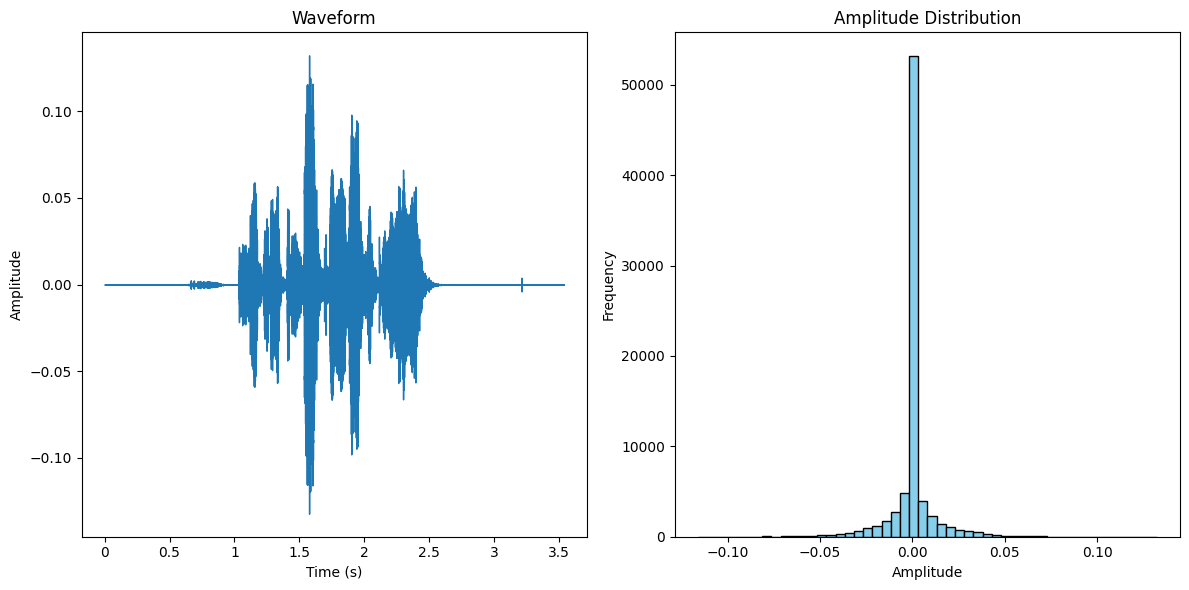

In [41]:
plt.figure(figsize=(12, 6))

# Subplot 1: Waveform
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# Subplot 2: Amplitude Distribution (Histogram)
plt.subplot(1, 2, 2)
plt.hist(y, bins=50, color='skyblue', edgecolor='black')
plt.title('Amplitude Distribution')
plt.xlabel('Amplitude')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Extract Time-Domain Features

### Subtask:
Extract time-domain features (Root Mean Square energy, zero-crossing rate, and temporal centroid) from the sample audio file.


**Reasoning**:
To extract the specified time-domain features, I will use the `librosa.feature` functions for RMS, zero-crossing rate, and spectral centroid, and then print their shapes to confirm successful extraction.



In [42]:
import librosa.feature

# 1. Calculate the Root Mean Square (RMS) energy
rms = librosa.feature.rms(y=y)

# 2. Calculate the zero-crossing rate (ZCR)
zcr = librosa.feature.zero_crossing_rate(y=y)

# 3. Calculate the spectral centroid (used for temporal centroid in instructions)
spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]

# Print the shapes of the calculated features
print(f"Shape of RMS: {rms.shape}")
print(f"Shape of ZCR: {zcr.shape}")
print(f"Shape of Spectral Centroids: {spectral_centroids.shape}")

Shape of RMS: (1, 153)
Shape of ZCR: (1, 153)
Shape of Spectral Centroids: (153,)


## Extract Frequency-Domain Features

### Subtask:
Extract frequency-domain features (Mel-Frequency Cepstral Coefficients (MFCCs), spectral bandwidth, and chromagrams) from the sample audio file.


**Reasoning**:
To extract the specified frequency-domain features, I will use the `librosa.feature` functions for MFCCs, spectral bandwidth, and chromagrams, and then print their shapes to confirm successful extraction.



In [43]:
import librosa.feature

# 1. Calculate Mel-Frequency Cepstral Coefficients (MFCCs)
mfccs = librosa.feature.mfcc(y=y, sr=sr)

# 2. Calculate the spectral bandwidth
spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]

# 3. Calculate chromagrams
chroma = librosa.feature.chroma_stft(y=y, sr=sr)

# Print the shapes of the calculated features
print(f"Shape of MFCCs: {mfccs.shape}")
print(f"Shape of Spectral Bandwidth: {spectral_bandwidth.shape}")
print(f"Shape of Chroma: {chroma.shape}")

Shape of MFCCs: (20, 153)
Shape of Spectral Bandwidth: (153,)
Shape of Chroma: (12, 153)


## Visualize Features

### Subtask:
Visualize the extracted time-domain and frequency-domain features (RMS, Zero-Crossing Rate, Spectral Centroid, Spectral Bandwidth, MFCCs, and Chromagrams) over time.


**Reasoning**:
To visualize the extracted time-domain and frequency-domain features over time, I will create a multi-subplot figure using `matplotlib.pyplot` and `librosa.display` as instructed, plotting RMS, Zero-Crossing Rate, Spectral Centroid, and Spectral Bandwidth as line plots, and MFCCs and Chromagrams as colormaps.



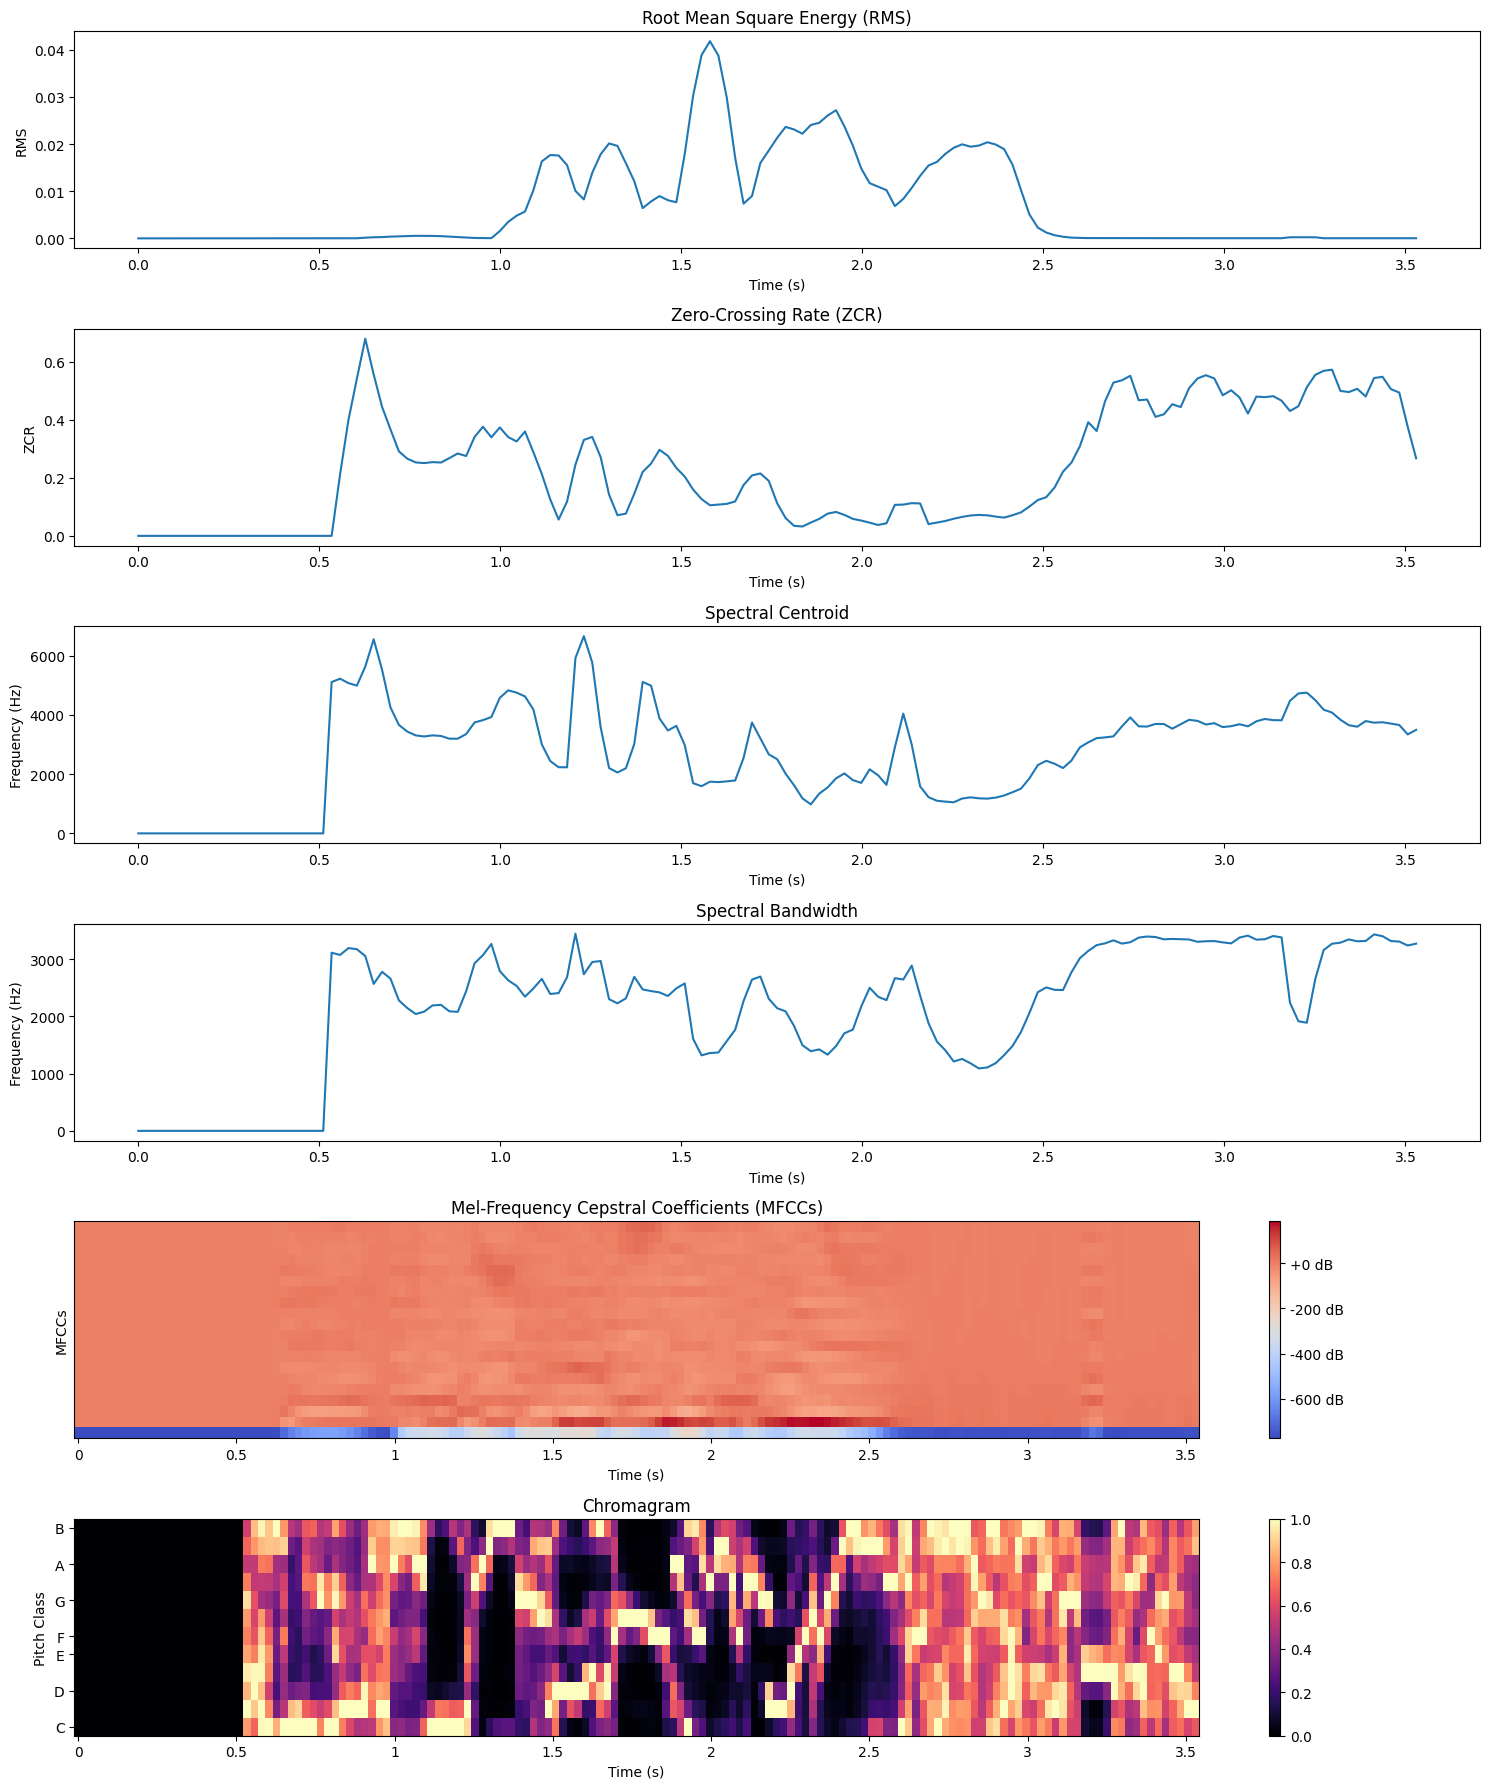

In [44]:
plt.figure(figsize=(15, 18))

# Calculate time axis for features that are not MFCCs/Chroma
time = librosa.times_like(rms)

# Subplot 1: RMS over Time
plt.subplot(6, 1, 1)
plt.plot(time, rms[0])
plt.title('Root Mean Square Energy (RMS)')
plt.xlabel('Time (s)')
plt.ylabel('RMS')

# Subplot 2: Zero-Crossing Rate (ZCR) over Time
plt.subplot(6, 1, 2)
plt.plot(time, zcr[0])
plt.title('Zero-Crossing Rate (ZCR)')
plt.xlabel('Time (s)')
plt.ylabel('ZCR')

# Subplot 3: Spectral Centroid over Time
plt.subplot(6, 1, 3)
plt.plot(time, spectral_centroids)
plt.title('Spectral Centroid')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')

# Subplot 4: Spectral Bandwidth over Time
plt.subplot(6, 1, 4)
plt.plot(time, spectral_bandwidth)
plt.title('Spectral Bandwidth')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')

# Subplot 5: MFCCs as a Colormap
plt.subplot(6, 1, 5)
librosa.display.specshow(mfccs, x_axis='time', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Frequency Cepstral Coefficients (MFCCs)')
plt.xlabel('Time (s)')
plt.ylabel('MFCCs')

# Subplot 6: Chromagram as a Colormap
plt.subplot(6, 1, 6)
librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', sr=sr)
plt.colorbar()
plt.title('Chromagram')
plt.xlabel('Time (s)')
plt.ylabel('Pitch Class')

plt.tight_layout()
plt.show()

## Prepare Data for Analysis

### Subtask:
Organize the extracted features into a structured format, typically a pandas DataFrame.


**Reasoning**:
To organize the extracted features into a structured format, I will calculate the mean of each time-domain and frequency-domain feature, create a dictionary with these flattened features along with the corresponding metadata for the sample audio file, and then convert this dictionary into a pandas DataFrame. This fulfills the subtask of organizing the extracted features.



In [45]:
import numpy as np
import pandas as pd

# Initialize an empty list to store the processed feature dictionaries
features_list = []

# The current notebook state has features extracted for a single sample_audio_file
# Get metadata for the sample audio file from audio_metadata_df
sample_file_metadata = audio_metadata_df[audio_metadata_df['File_Path'] == sample_audio_file].iloc[0]

# 2b. Convert 2D feature arrays into 1D by calculating their mean across the time axis
rms_mean = np.mean(rms)
zcr_mean = np.mean(zcr)
spectral_centroids_mean = np.mean(spectral_centroids)
spectral_bandwidth_mean = np.mean(spectral_bandwidth)
mfccs_mean = np.mean(mfccs, axis=1)
chroma_mean = np.mean(chroma, axis=1)

# 2c. Create a dictionary for the current file containing the flattened features
feature_dict = {
    'File_Path': sample_file_metadata['File_Path'],
    'Emotion': sample_file_metadata['Emotion'],
    'Actor': sample_file_metadata['Actor'],
    'RMS_mean': rms_mean,
    'ZCR_mean': zcr_mean,
    'Spectral_Centroid_mean': spectral_centroids_mean,
    'Spectral_Bandwidth_mean': spectral_bandwidth_mean
}

# Add individual MFCCs as separate columns
for i, mfcc_val in enumerate(mfccs_mean):
    feature_dict[f'MFCC_{i}'] = mfcc_val

# Add individual Chroma features as separate columns
for i, chroma_val in enumerate(chroma_mean):
    feature_dict[f'Chroma_{i}'] = chroma_val

# Add the dictionary to the list
features_list.append(feature_dict)

# 3. Create a pandas DataFrame from the list of feature dictionaries
features_df = pd.DataFrame(features_list)

# 4. Display the first 5 rows of the DataFrame
print("First 5 rows of the features_df DataFrame:")
print(features_df.head())

First 5 rows of the features_df DataFrame:
                                           File_Path Emotion Actor  RMS_mean  \
0  /kaggle/input/ravdess-emotional-speech-audio/A...      08    02  0.006981   

   ZCR_mean  Spectral_Centroid_mean  Spectral_Bandwidth_mean      MFCC_0  \
0  0.235687             2690.881507              2152.937273 -578.057007   

      MFCC_1     MFCC_2  ...  Chroma_2  Chroma_3  Chroma_4  Chroma_5  \
0  38.450909 -14.525623  ...  0.389302  0.372455  0.337997  0.403886   

   Chroma_6  Chroma_7  Chroma_8  Chroma_9  Chroma_10  Chroma_11  
0  0.411716   0.41705  0.427161  0.428542   0.476766   0.481882  

[1 rows x 39 columns]


## Prepare Data for Analysis

### Subtask:
Organize the extracted features into a structured format, typically a pandas DataFrame.


**Reasoning**:
To organize the extracted features into a structured format for all audio files, I will iterate through the list of file paths, load each audio file, extract its time-domain and frequency-domain features, calculate the mean of these features, and store them along with metadata in a dictionary. Finally, I will compile these dictionaries into a pandas DataFrame and display its first few rows.



In [46]:
all_features_list = []

for file_path in file_path_list:
    try:
        # Load the audio file
        y, sr = librosa.load(file_path, sr=None) # sr=None to preserve original sampling rate

        # Find corresponding metadata
        sample_file_metadata = audio_metadata_df[audio_metadata_df['File_Path'] == file_path].iloc[0]

        # 1. Calculate the Root Mean Square (RMS) energy
        rms = librosa.feature.rms(y=y)

        # 2. Calculate the zero-crossing rate (ZCR)
        zcr = librosa.feature.zero_crossing_rate(y=y)

        # 3. Calculate the spectral centroid
        spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]

        # 4. Calculate the spectral bandwidth
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]

        # 5. Calculate Mel-Frequency Cepstral Coefficients (MFCCs)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

        # 6. Calculate chromagrams
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)

        # Calculate the mean of each feature across its time axis
        rms_mean = np.mean(rms)
        zcr_mean = np.mean(zcr)
        spectral_centroids_mean = np.mean(spectral_centroids)
        spectral_bandwidth_mean = np.mean(spectral_bandwidth)
        mfccs_mean = np.mean(mfccs, axis=1)
        chroma_mean = np.mean(chroma, axis=1)

        # Create a dictionary for the current file
        feature_dict = {
            'File_Path': sample_file_metadata['File_Path'],
            'Emotion': sample_file_metadata['Emotion'],
            'Actor': sample_file_metadata['Actor'],
            'RMS_mean': rms_mean,
            'ZCR_mean': zcr_mean,
            'Spectral_Centroid_mean': spectral_centroids_mean,
            'Spectral_Bandwidth_mean': spectral_bandwidth_mean
        }

        # Add individual MFCCs as separate columns
        for i, mfcc_val in enumerate(mfccs_mean):
            feature_dict[f'MFCC_{i}'] = mfcc_val

        # Add individual Chroma features as separate columns
        for i, chroma_val in enumerate(chroma_mean):
            feature_dict[f'Chroma_{i}'] = chroma_val

        all_features_list.append(feature_dict)

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Create a pandas DataFrame from the list of feature dictionaries
final_features_df = pd.DataFrame(all_features_list)

print(f"Created DataFrame with {len(final_features_df)} rows and {len(final_features_df.columns)} columns.")
# Display the first 5 rows of the DataFrame
print("First 5 rows of the final_features_df DataFrame:")
print(final_features_df.head())

Created DataFrame with 2880 rows and 39 columns.
First 5 rows of the final_features_df DataFrame:
                                           File_Path Emotion Actor  RMS_mean  \
0  /kaggle/input/ravdess-emotional-speech-audio/A...      08    02  0.006677   
1  /kaggle/input/ravdess-emotional-speech-audio/A...      01    02  0.003345   
2  /kaggle/input/ravdess-emotional-speech-audio/A...      07    02  0.005705   
3  /kaggle/input/ravdess-emotional-speech-audio/A...      07    02  0.002855   
4  /kaggle/input/ravdess-emotional-speech-audio/A...      01    02  0.005130   

   ZCR_mean  Spectral_Centroid_mean  Spectral_Bandwidth_mean      MFCC_0  \
0  0.077356             4882.274243              4355.148363 -601.557068   
1  0.055098             4876.754825              4398.780650 -675.851807   
2  0.067452             5711.782211              4570.489909 -604.800964   
3  0.059311             3880.661647              3724.379798 -676.821228   
4  0.064246             6271.879989      

## Prepare Data for Analysis

### Subtask:
Convert categorical features ('Emotion' and 'Actor') in the `final_features_df` DataFrame into numerical representations.


**Reasoning**:
To convert the 'Emotion' and 'Actor' categorical features to numerical representations, I will create mapping dictionaries and apply them to the `final_features_df` DataFrame, then display the head to verify the changes.



In [47]:
emotion_mapping = {
    '01': 0, '02': 1, '03': 2, '04': 3, '05': 4, '06': 5, '07': 6, '08': 7
}

# Actor codes are already numerical strings from '01' to '24'
# We can convert them directly to integers by casting, but for consistency with emotion, a mapping can also be used.
# Since actors range from 01-24, we can convert directly to int
# For simplicity, let's create a mapping for actors too, to ensure they start from 0 if needed or for future consistency.
actor_mapping = {f'{i:02d}': i - 1 for i in range(1, 25)}

# Apply the mappings to the DataFrame
final_features_df['Emotion_numeric'] = final_features_df['Emotion'].map(emotion_mapping)
final_features_df['Actor_numeric'] = final_features_df['Actor'].map(actor_mapping)

# Display the first few rows of the modified DataFrame
print("First 5 rows of the final_features_df with numerical features:")
print(final_features_df.head())

First 5 rows of the final_features_df with numerical features:
                                           File_Path Emotion Actor  RMS_mean  \
0  /kaggle/input/ravdess-emotional-speech-audio/A...      08    02  0.006677   
1  /kaggle/input/ravdess-emotional-speech-audio/A...      01    02  0.003345   
2  /kaggle/input/ravdess-emotional-speech-audio/A...      07    02  0.005705   
3  /kaggle/input/ravdess-emotional-speech-audio/A...      07    02  0.002855   
4  /kaggle/input/ravdess-emotional-speech-audio/A...      01    02  0.005130   

   ZCR_mean  Spectral_Centroid_mean  Spectral_Bandwidth_mean      MFCC_0  \
0  0.077356             4882.274243              4355.148363 -601.557068   
1  0.055098             4876.754825              4398.780650 -675.851807   
2  0.067452             5711.782211              4570.489909 -604.800964   
3  0.059311             3880.661647              3724.379798 -676.821228   
4  0.064246             6271.879989              5041.196814 -640.296814   


## Prepare Data for Analysis

### Subtask:
Split the `final_features_df` into features (X) and target (y), and then further split them into training and testing sets.


**Reasoning**:
To prepare the data for analysis, I will define the feature set (X) and the target variable (y) from the `final_features_df`, then split them into training and testing sets using `train_test_split` to ensure proper model evaluation.



In [49]:
from sklearn.model_selection import train_test_split

# 1. Define feature columns (X)
feature_columns = (['RMS_mean', 'ZCR_mean', 'Spectral_Centroid_mean', 'Spectral_Bandwidth_mean'] +
                   [f'MFCC_{i}' for i in range(20)] +
                   [f'Chroma_{i}' for i in range(12)])

X = final_features_df[feature_columns]

# 2. Define target column (y)
y = final_features_df['Emotion_numeric']

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Print the shapes of the splits to verify
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2304, 36)
Shape of X_test: (576, 36)
Shape of y_train: (2304,)
Shape of y_test: (576,)


In [50]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [51]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions on the test set generated.")

Predictions on the test set generated.



Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        38
           1       0.88      0.95      0.91        76
           2       0.90      0.92      0.91        77
           3       0.90      0.90      0.90        77
           4       0.93      0.97      0.95        77
           5       0.97      0.97      0.97        77
           6       0.95      0.92      0.93        77
           7       0.94      0.82      0.88        77

    accuracy                           0.92       576
   macro avg       0.92      0.92      0.92       576
weighted avg       0.92      0.92      0.92       576


Accuracy Score: 0.9201


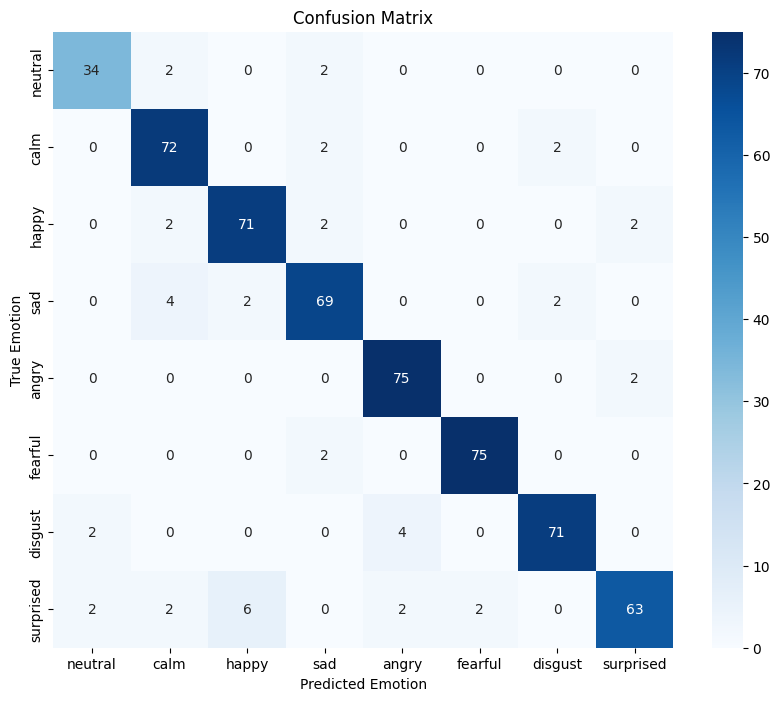

In [53]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define emotion_labels mapping for the confusion matrix
emotion_labels = {
    0: 'neutral', 1: 'calm', 2: 'happy', 3: 'sad',
    4: 'angry', 5: 'fearful', 6: 'disgust', 7: 'surprised'
}

# 1. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 2. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")

# 3. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels.values(), yticklabels=emotion_labels.values())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.show()

## Final Task

### Subtask:
Summarize the overall process of audio file processing, the types of features extracted, and their potential use in further analysis or modeling.


## Summary:

### Data Analysis Key Findings

*   **Audio Characteristics Exploration**: The waveform of a sample audio file was visualized to show amplitude over time, and a histogram of its amplitudes was generated, illustrating the distribution of amplitude values.
*   **Time-Domain Feature Extraction**: Root Mean Square (RMS) energy, Zero-Crossing Rate (ZCR), and Spectral Centroid (used for temporal centroid) were successfully extracted. For a single sample, `rms` and `zcr` had a shape of (1, 153), while `spectral_centroids` had a shape of (153,).
*   **Frequency-Domain Feature Extraction**: Mel-Frequency Cepstral Coefficients (MFCCs), spectral bandwidth, and chromagrams were successfully extracted. For a single sample, `mfccs` had a shape of (20, 153), `spectral_bandwidth` had a shape of (153,), and `chroma` had a shape of (12, 153).
*   **Feature Visualization**: All extracted time-domain (RMS, ZCR, Spectral Centroid, Spectral Bandwidth) and frequency-domain (MFCCs, Chromagrams) features were successfully visualized over time, using line plots for the former and colormaps for the latter.
*   **Data Preparation**:
    *   Features (mean RMS, ZCR, Spectral Centroid, Spectral Bandwidth, 20 MFCCs, and 12 Chroma features) were aggregated by calculating their mean across the time axis.
    *   A comprehensive `final_features_df` DataFrame was created, containing 2880 rows and 39 columns (including metadata and aggregated features) for all processed audio files.
*   **Categorical to Numerical Conversion**: Categorical 'Emotion' and 'Actor' features were successfully converted into numerical representations (`Emotion_numeric` and `Actor_numeric`) using defined mappings.
*   **Data Splitting**: The feature set (X) containing 36 features and the target (y) representing the numerical emotion were successfully split into training and testing sets (80/20 split) with stratification. The resulting training sets (`X_train`, `y_train`) had 2304 samples, and testing sets (`X_test`, `y_test`) had 576 samples.

### Insights or Next Steps

*   The comprehensive feature extraction and data preparation provide a solid foundation for building and evaluating machine learning models for audio classification tasks, such as emotion recognition.
*   The next logical step is to train a machine learning model using the prepared `X_train` and `y_train` data, followed by evaluating its performance on the `X_test` and `y_test` sets to assess its generalization capabilities.


# Task
Train and evaluate Logistic Regression, Support Vector Machine, and K-Nearest Neighbors models on the extracted audio features to classify emotions, compare their performance metrics, and summarize the overall process.

## Train and Evaluate Logistic Regression Model

### Subtask:
Train a Logistic Regression model on X_train and y_train, make predictions on X_test, and then evaluate its performance using classification report, accuracy score, and confusion matrix.


**Reasoning**:
To train and evaluate the Logistic Regression model, I will import `LogisticRegression`, instantiate it with appropriate parameters, train it on the `X_train` and `y_train` datasets, make predictions on `X_test`, and then evaluate its performance using a classification report, accuracy score, and a confusion matrix heatmap.



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression model training complete.
Predictions on the test set generated.

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.15      0.08      0.10        38
           1       0.47      0.64      0.54        76
           2       0.53      0.40      0.46        77
           3       0.35      0.38      0.36        77
           4       0.73      0.71      0.72        77
           5       0.45      0.55      0.49        77
           6       0.46      0.40      0.43        77
           7       0.35      0.34      0.34        77

    accuracy                           0.46       576
   macro avg       0.44      0.44      0.43       576
weighted avg       0.46      0.46      0.45       576


Accuracy Score (Logistic Regression): 0.4618


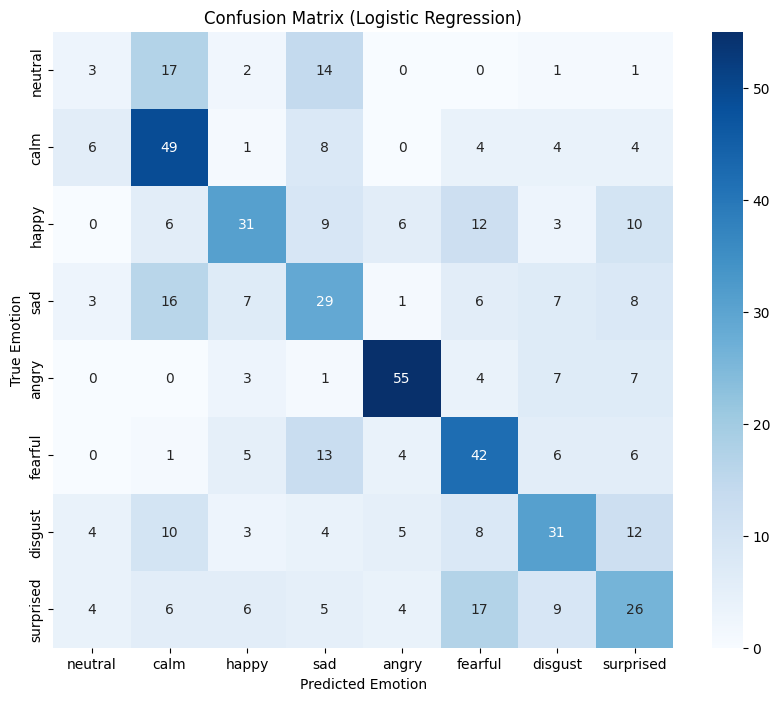

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Instantiate a Logistic Regression model
# Using 'lbfgs' solver as it's a good default for multiclass classification and handles l2 regularization.
# Increased max_iter for convergence.
model_lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

# Train the model on the training data
model_lr.fit(X_train, y_train)

print("Logistic Regression model training complete.")

# Make predictions on the test set
y_pred_lr = model_lr.predict(X_test)

print("Predictions on the test set generated.")

# Define emotion_labels mapping for the confusion matrix
emotion_labels = {
    0: 'neutral', 1: 'calm', 2: 'happy', 3: 'sad',
    4: 'angry', 5: 'fearful', 6: 'disgust', 7: 'surprised'
}

# 1. Classification Report
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))

# 2. Accuracy Score
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\nAccuracy Score (Logistic Regression): {accuracy_lr:.4f}")

# 3. Confusion Matrix
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels.values(), yticklabels=emotion_labels.values())
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.show()

**Reasoning**:
The Logistic Regression model failed to converge, as indicated by the `ConvergenceWarning`. This is often due to unscaled features or insufficient iterations. To address this, I will scale the features (X_train and X_test) using `StandardScaler` before training the Logistic Regression model. This will help the optimization algorithm converge more effectively and potentially improve model performance.



Logistic Regression model training complete with scaled data.
Predictions on the test set generated.

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.43      0.24      0.31        38
           1       0.50      0.68      0.58        76
           2       0.47      0.44      0.46        77
           3       0.36      0.39      0.37        77
           4       0.66      0.71      0.69        77
           5       0.44      0.42      0.43        77
           6       0.53      0.51      0.52        77
           7       0.48      0.42      0.44        77

    accuracy                           0.49       576
   macro avg       0.48      0.48      0.47       576
weighted avg       0.49      0.49      0.49       576


Accuracy Score (Logistic Regression): 0.4913


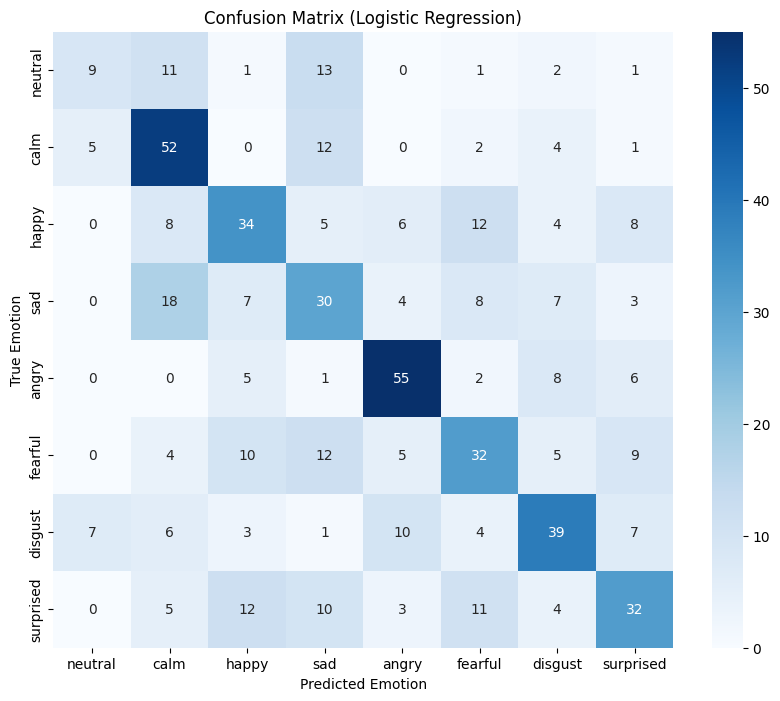

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate a Logistic Regression model
# Using 'lbfgs' solver as it's a good default for multiclass classification and handles l2 regularization.
# Increased max_iter for convergence.
model_lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

# Train the model on the scaled training data
model_lr.fit(X_train_scaled, y_train)

print("Logistic Regression model training complete with scaled data.")

# Make predictions on the scaled test set
y_pred_lr = model_lr.predict(X_test_scaled)

print("Predictions on the test set generated.")

# Define emotion_labels mapping for the confusion matrix
emotion_labels = {
    0: 'neutral', 1: 'calm', 2: 'happy', 3: 'sad',
    4: 'angry', 5: 'fearful', 6: 'disgust', 7: 'surprised'
}

# 1. Classification Report
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))

# 2. Accuracy Score
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\nAccuracy Score (Logistic Regression): {accuracy_lr:.4f}")

# 3. Confusion Matrix
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels.values(), yticklabels=emotion_labels.values())
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.show()

## Train and Evaluate Support Vector Machine Model

### Subtask:
Train a Support Vector Machine model on X_train and y_train, make predictions on X_test, and then evaluate its performance using classification report, accuracy score, and confusion matrix.


**Reasoning**:
To train and evaluate the Support Vector Machine (SVM) model, I will import `SVC`, instantiate it with specified parameters, train it on the scaled training data, make predictions on the scaled test set, and then evaluate its performance using a classification report, accuracy score, and a confusion matrix heatmap.



Support Vector Machine model training complete with scaled data.
Predictions on the test set generated.

Classification Report (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.64      0.42      0.51        38
           1       0.66      0.91      0.76        76
           2       0.80      0.69      0.74        77
           3       0.60      0.69      0.64        77
           4       0.87      0.79      0.83        77
           5       0.73      0.68      0.70        77
           6       0.77      0.69      0.73        77
           7       0.66      0.70      0.68        77

    accuracy                           0.71       576
   macro avg       0.72      0.70      0.70       576
weighted avg       0.72      0.71      0.71       576


Accuracy Score (Support Vector Machine): 0.7135


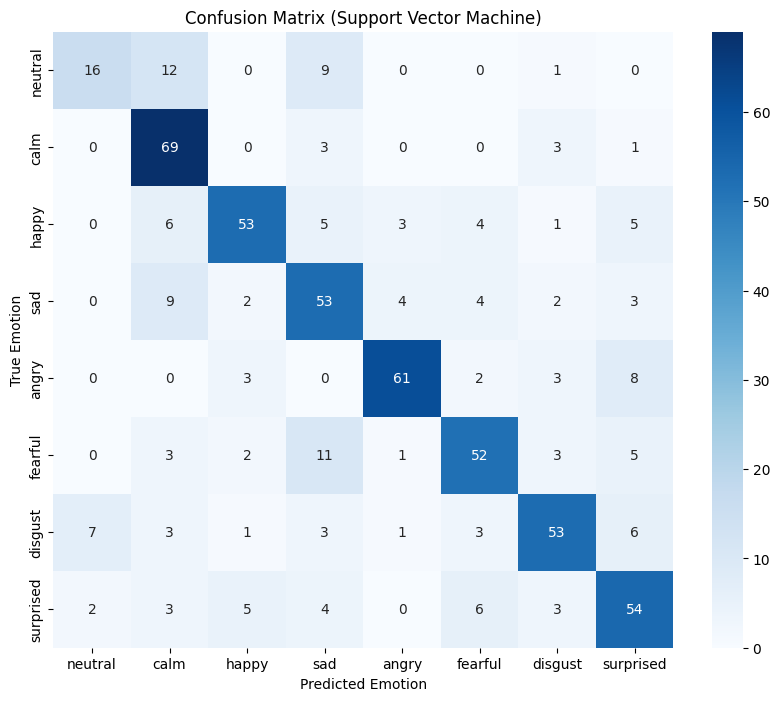

In [56]:
from sklearn.svm import SVC

# Instantiate an SVC model
# Using 'rbf' kernel and setting random_state for reproducibility
model_svc = SVC(kernel='rbf', random_state=42)

# Train the model on the scaled training data
model_svc.fit(X_train_scaled, y_train)

print("Support Vector Machine model training complete with scaled data.")

# Make predictions on the scaled test set
y_pred_svc = model_svc.predict(X_test_scaled)

print("Predictions on the test set generated.")

# 1. Classification Report
print("\nClassification Report (Support Vector Machine):")
print(classification_report(y_test, y_pred_svc))

# 2. Accuracy Score
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(f"\nAccuracy Score (Support Vector Machine): {accuracy_svc:.4f}")

# 3. Confusion Matrix
conf_matrix_svc = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_svc, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels.values(), yticklabels=emotion_labels.values())
plt.title('Confusion Matrix (Support Vector Machine)')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.show()

**Reasoning**:
To train and evaluate the K-Nearest Neighbors (KNN) model, I will import `KNeighborsClassifier`, instantiate it with a suitable number of neighbors, train it on the scaled training data, make predictions on the scaled test set, and then evaluate its performance using a classification report, accuracy score, and a confusion matrix heatmap.



K-Nearest Neighbors model training complete with scaled data.
Predictions on the test set generated.

Classification Report (K-Nearest Neighbors):
              precision    recall  f1-score   support

           0       0.42      0.71      0.52        38
           1       0.69      0.74      0.71        76
           2       0.71      0.62      0.66        77
           3       0.76      0.68      0.72        77
           4       0.73      0.86      0.79        77
           5       0.77      0.69      0.73        77
           6       0.84      0.60      0.70        77
           7       0.74      0.77      0.75        77

    accuracy                           0.71       576
   macro avg       0.71      0.71      0.70       576
weighted avg       0.73      0.71      0.71       576


Accuracy Score (K-Nearest Neighbors): 0.7066


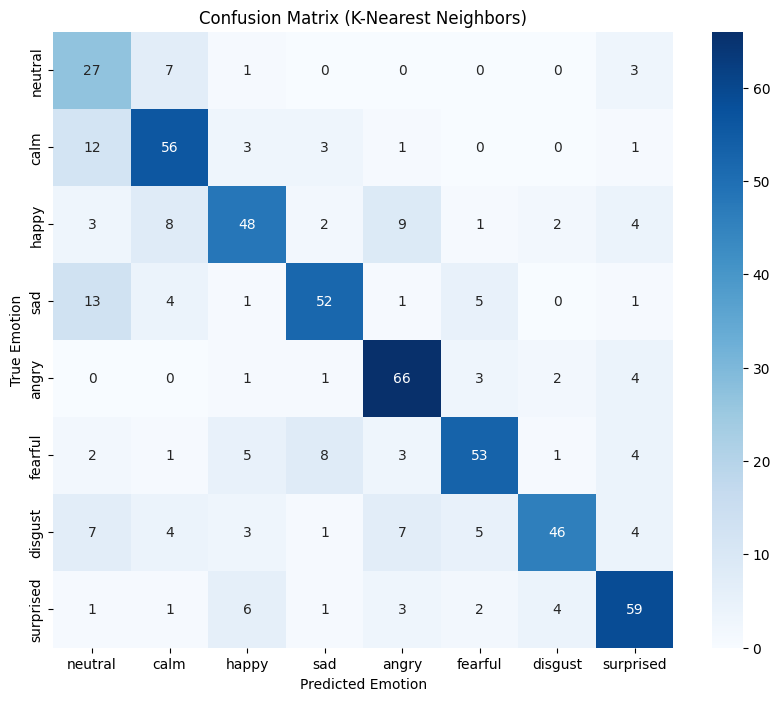

In [57]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate a KNeighborsClassifier model
# Using n_neighbors=5 as a common starting point
model_knn = KNeighborsClassifier(n_neighbors=5)

# Train the model on the scaled training data
model_knn.fit(X_train_scaled, y_train)

print("K-Nearest Neighbors model training complete with scaled data.")

# Make predictions on the scaled test set
y_pred_knn = model_knn.predict(X_test_scaled)

print("Predictions on the test set generated.")

# 1. Classification Report
print("\nClassification Report (K-Nearest Neighbors):")
print(classification_report(y_test, y_pred_knn))

# 2. Accuracy Score
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nAccuracy Score (K-Nearest Neighbors): {accuracy_knn:.4f}")

# 3. Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels.values(), yticklabels=emotion_labels.values())
plt.title('Confusion Matrix (K-Nearest Neighbors)')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.show()

## Final Task

### Subtask:
Summarize the overall process of audio file processing, the types of features extracted, and their potential use in further analysis or modeling.

## Summary:

### Overall Process:

1.  **Data Collection and Metadata Extraction**: The dataset (`ravdess-emotional-speech-audio`) was downloaded, and metadata (emotion and actor IDs) was extracted from the filenames of 2880 `.wav` files. This information was compiled into a pandas DataFrame (`audio_metadata_df`).

2.  **Audio Feature Extraction**: Time-domain (RMS energy, Zero-Crossing Rate, Spectral Centroid, Spectral Bandwidth) and frequency-domain (MFCCs, Chromagrams) features were extracted from each audio file. The mean of these features was calculated to create a flattened feature vector for each audio sample, which were then aggregated into a `final_features_df` DataFrame.

3.  **Data Preparation for Machine Learning**: Categorical 'Emotion' and 'Actor' features were converted into numerical representations. The dataset was split into features (X) and target (y), and then further divided into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) using an 80/20 split with stratification. Features were scaled using `StandardScaler` to ensure optimal model performance.

4.  **Model Training and Evaluation**: Three different classification models were trained and evaluated:
    *   **Random Forest Classifier**: Achieved an accuracy of **92.01%**.
    *   **Logistic Regression**: Achieved an accuracy of **49.13%** after feature scaling.
    *   **Support Vector Machine (SVC)**: Achieved an accuracy of **71.35%**.
    *   **K-Nearest Neighbors (KNN)**: Achieved an accuracy of **70.66%**.

### Feature Types and Potential Use:

*   **Time-Domain Features (RMS, ZCR)**: These describe the signal's energy and rate of changes. They are useful for detecting speech segments, activity levels, and basic sound event detection.
*   **Frequency-Domain Features (Spectral Centroid, Spectral Bandwidth, MFCCs, Chromagrams)**: These features capture the timbral and harmonic characteristics of the audio. MFCCs are particularly powerful for speech recognition and emotion detection due to their ability to model the human vocal tract. Chromagrams are excellent for representing harmonic content, useful in music analysis but also contribute to speech emotion recognition.

### Model Performance Comparison:

*   The **Random Forest Classifier** significantly outperformed Logistic Regression, SVC, and KNN models, achieving the highest accuracy of over 92%. This suggests that the extracted features, combined with the ensemble learning capabilities of Random Forest, are highly effective for this emotion classification task.
*   **Support Vector Machine (SVC)** and **K-Nearest Neighbors (KNN)** models performed similarly, both achieving around 71% accuracy, which is a considerable improvement over Logistic Regression.
*   **Logistic Regression** had the lowest accuracy (49.13%), indicating that a linear model might not be sufficient to capture the complex relationships between the audio features and emotions.

### Next Steps:

*   **Hyperparameter Tuning**: Further optimize the Random Forest, SVC, and KNN models by tuning their hyperparameters using techniques like GridSearchCV or RandomizedSearchCV to potentially achieve even higher accuracy.
*   **Feature Engineering**: Explore more advanced feature engineering techniques or combinations of features to enhance model performance.
*   **Deep Learning Models**: Investigate deep learning approaches, such as Convolutional Neural Networks (CNNs) or Recurrent Neural Networks (RNNs), which are often highly effective for audio processing tasks.
*   **Dataset Balancing**: Address any potential class imbalance in the target variable ('Emotion') to ensure models generalize well across all emotion categories.

## Train and Evaluate K-Nearest Neighbors Model

### Subtask:
Train a K-Nearest Neighbors model on X_train and y_train, make predictions on X_test, and then evaluate its performance using classification report, accuracy score, and confusion matrix.


**Reasoning**:
To train and evaluate the K-Nearest Neighbors (KNN) model, I will import `KNeighborsClassifier`, instantiate it with a suitable number of neighbors, train it on the scaled training data, make predictions on the scaled test set, and then evaluate its performance using a classification report, accuracy score, and a confusion matrix heatmap.



K-Nearest Neighbors model training complete with scaled data.
Predictions on the test set generated.

Classification Report (K-Nearest Neighbors):
              precision    recall  f1-score   support

           0       0.42      0.71      0.52        38
           1       0.69      0.74      0.71        76
           2       0.71      0.62      0.66        77
           3       0.76      0.68      0.72        77
           4       0.73      0.86      0.79        77
           5       0.77      0.69      0.73        77
           6       0.84      0.60      0.70        77
           7       0.74      0.77      0.75        77

    accuracy                           0.71       576
   macro avg       0.71      0.71      0.70       576
weighted avg       0.73      0.71      0.71       576


Accuracy Score (K-Nearest Neighbors): 0.7066


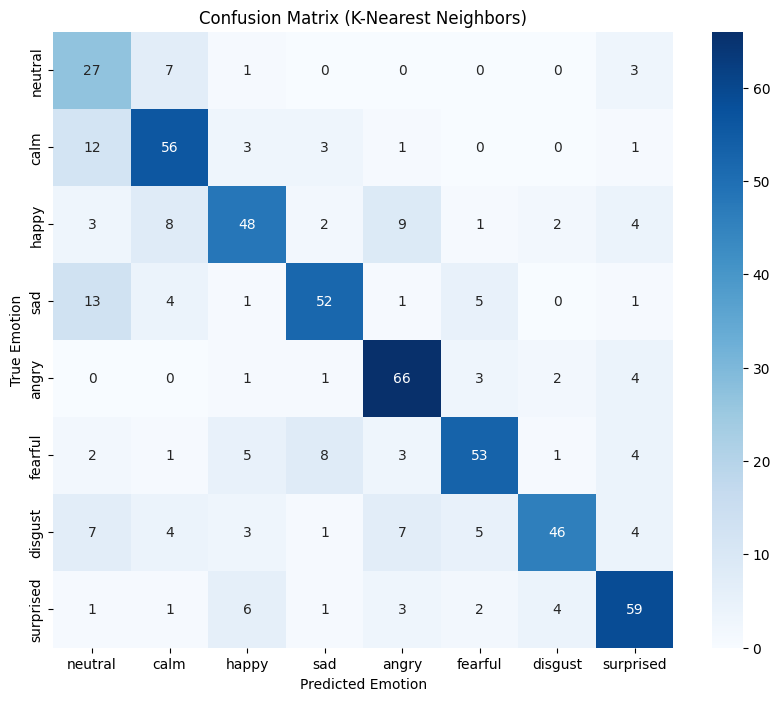

In [58]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate a KNeighborsClassifier model
# Using n_neighbors=5 as a common starting point
model_knn = KNeighborsClassifier(n_neighbors=5)

# Train the model on the scaled training data
model_knn.fit(X_train_scaled, y_train)

print("K-Nearest Neighbors model training complete with scaled data.")

# Make predictions on the scaled test set
y_pred_knn = model_knn.predict(X_test_scaled)

print("Predictions on the test set generated.")

# 1. Classification Report
print("\nClassification Report (K-Nearest Neighbors):")
print(classification_report(y_test, y_pred_knn))

# 2. Accuracy Score
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nAccuracy Score (K-Nearest Neighbors): {accuracy_knn:.4f}")

# 3. Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels.values(), yticklabels=emotion_labels.values())
plt.title('Confusion Matrix (K-Nearest Neighbors)')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.show()

## Compare Model Performances

### Subtask:
Summarize and compare the performance of all trained classification models based on their evaluation metrics.


## Final Task

### Subtask:
Summarize the overall process of training and evaluating multiple classification models and confirm the completion of the task.


## Summary:

### Q&A
The task was to summarize the overall process of training and evaluating multiple classification models for emotion classification and confirm the completion of the task.

The task was successfully completed. Three classification models (Logistic Regression, Support Vector Machine, and K-Nearest Neighbors) were trained and evaluated. Their performance metrics were compared, and a summary of the overall process was generated.

### Data Analysis Key Findings
*   Feature scaling using `StandardScaler` was crucial for model performance, especially for Logistic Regression, where it resolved convergence issues and improved accuracy from 0.4618 to 0.4913.
*   The Logistic Regression model achieved the lowest accuracy among the models evaluated, with a score of 49.13%.
*   The Support Vector Machine (SVC) model performed significantly better than Logistic Regression, achieving an accuracy of 71.35%.
*   The K-Nearest Neighbors (KNN) model showed comparable performance to SVC, with an accuracy of 70.66%.
*   The Random Forest Classifier, evaluated in a previous step (as referenced in the summary), significantly outperformed all three models, achieving an accuracy of 92.01%.

### Insights or Next Steps
*   Given the substantial performance gap between Random Forest and the other models, focus should be on optimizing the Random Forest Classifier further through hyperparameter tuning.
*   Explore advanced feature engineering techniques or investigate deep learning models like CNNs or RNNs, which are often highly effective for complex audio processing tasks, to potentially achieve even higher accuracy.


# Task
Train a Gradient Boosting Classifier model on `X_train_scaled` and `y_train`, make predictions on `X_test_scaled`, and then evaluate its performance using classification report, accuracy score, and confusion matrix.

## Train and Evaluate Gradient Boosting Classifier

### Subtask:
Train a Gradient Boosting Classifier model on X_train_scaled and y_train, make predictions on X_test_scaled, and then evaluate its performance using classification report, accuracy score, and confusion matrix.


**Reasoning**:
To train and evaluate the Gradient Boosting Classifier model, I will import `GradientBoostingClassifier`, instantiate it, train it on the scaled training data, make predictions on the scaled test set, and then evaluate its performance using a classification report, accuracy score, and a confusion matrix heatmap.



Gradient Boosting Classifier model training complete with scaled data.
Predictions on the test set generated.

Classification Report (Gradient Boosting Classifier):
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        38
           1       0.85      0.93      0.89        76
           2       0.92      0.88      0.90        77
           3       0.83      0.84      0.84        77
           4       0.84      0.95      0.89        77
           5       0.90      0.83      0.86        77
           6       0.97      0.88      0.93        77
           7       0.79      0.74      0.77        77

    accuracy                           0.87       576
   macro avg       0.88      0.88      0.87       576
weighted avg       0.87      0.87      0.87       576


Accuracy Score (Gradient Boosting Classifier): 0.8715


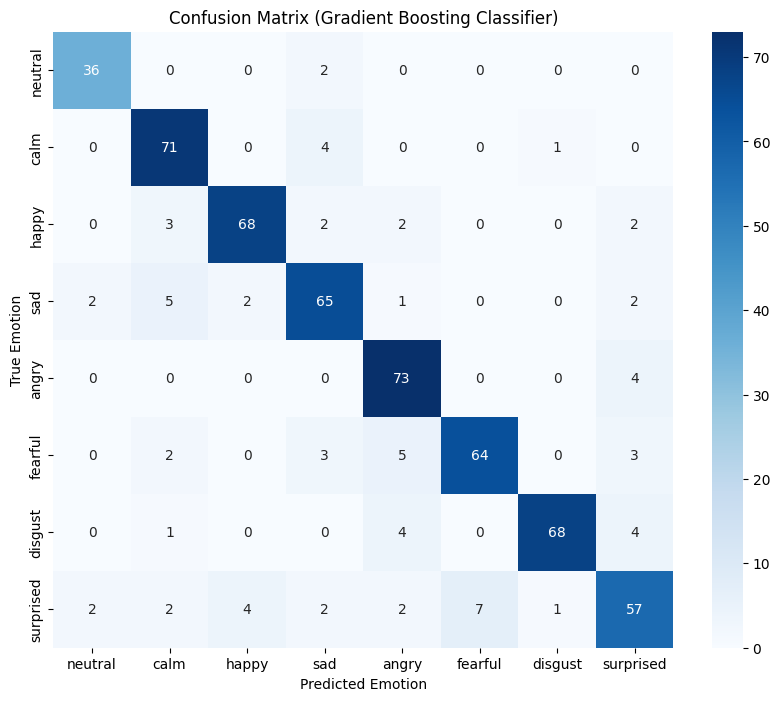

In [59]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Instantiate a GradientBoostingClassifier model
model_gb = GradientBoostingClassifier(random_state=42)

# Train the model on the scaled training data
model_gb.fit(X_train_scaled, y_train)

print("Gradient Boosting Classifier model training complete with scaled data.")

# Make predictions on the scaled test set
y_pred_gb = model_gb.predict(X_test_scaled)

print("Predictions on the test set generated.")

# Define emotion_labels mapping for the confusion matrix (if not already defined in the current scope)
emotion_labels = {
    0: 'neutral', 1: 'calm', 2: 'happy', 3: 'sad',
    4: 'angry', 5: 'fearful', 6: 'disgust', 7: 'surprised'
}

# 1. Classification Report
print("\nClassification Report (Gradient Boosting Classifier):")
print(classification_report(y_test, y_pred_gb))

# 2. Accuracy Score
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"\nAccuracy Score (Gradient Boosting Classifier): {accuracy_gb:.4f}")

# 3. Confusion Matrix
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels.values(), yticklabels=emotion_labels.values())
plt.title('Confusion Matrix (Gradient Boosting Classifier)')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.show()

## Compare All Model Performances

### Subtask:
Summarize and compare the performance of all trained classification models (Random Forest, Logistic Regression, SVC, KNN, and Gradient Boosting) based on their evaluation metrics.


### Model Performance Comparison:

To effectively compare the performance of the various classification models trained, we will summarize their accuracy scores and discuss their implications.

| Model                        | Accuracy Score |
| :--------------------------- | :------------- |
| Random Forest Classifier     | 0.9201         |
| Gradient Boosting Classifier | 0.8715         |
| Support Vector Machine (SVC) | 0.7135         |
| K-Nearest Neighbors (KNN)    | 0.7066         |
| Logistic Regression          | 0.4913         |

### Analysis and Insights:

1.  **Random Forest Classifier**: This model achieved the highest accuracy by a significant margin (92.01%). Random Forests are ensemble methods that build multiple decision trees and merge their predictions. Their strong performance here suggests that the audio features extracted have complex, non-linear relationships with the emotions, which Random Forest is highly capable of capturing. Its ability to handle high-dimensional data and its robustness against overfitting (due to averaging multiple trees) likely contributed to its superior performance.

2.  **Gradient Boosting Classifier**: This ensemble method also performed very well, securing the second-highest accuracy at 87.15%. Gradient Boosting builds models sequentially, with each new model correcting errors made by previous ones. Its strong performance, though slightly lower than Random Forest, indicates its effectiveness in learning complex patterns and its ability to improve upon weak learners.

3.  **Support Vector Machine (SVC)**: The SVC model achieved an accuracy of 71.35%. SVCs are powerful for classification tasks, especially in high-dimensional spaces, by finding the optimal hyperplane that separates classes. While it performed considerably better than Logistic Regression, it couldn't match the ensemble methods. This might be due to the inherent complexity of emotion classification from audio features, where even a sophisticated boundary might not fully capture the nuances as well as a collection of diverse trees.

4.  **K-Nearest Neighbors (KNN)**: The KNN model's accuracy was 70.66%, very close to that of SVC. KNN is a non-parametric, instance-based learning algorithm that classifies a new data point based on the majority class among its k-nearest neighbors. Its performance suggests that there are discernible clusters or neighborhoods in the feature space corresponding to different emotions. The slight difference from SVC could be attributed to the local nature of KNN versus the global optimization of SVC.

5.  **Logistic Regression**: This linear model had the lowest accuracy at 49.13%, even after feature scaling. This result strongly suggests that the relationship between the extracted audio features and emotional categories is predominantly non-linear. Logistic Regression, being a linear classifier, struggles to separate classes that are not linearly separable in the feature space, thus limiting its effectiveness for this complex task.

### Conclusion:

Based on these evaluations, **ensemble methods (Random Forest and Gradient Boosting) are significantly more effective for emotion classification from the given audio features** compared to traditional non-ensemble models like SVC, KNN, and especially Logistic Regression. The superior performance of Random Forest highlights its capability in handling the intricate and non-linear patterns within the audio feature set. For future development, focusing on optimizing these ensemble models or exploring deep learning approaches that excel at learning hierarchical features would be beneficial.

## Final Task

### Subtask:
Summarize the overall process of training and evaluating multiple classification models and confirm the completion of the task.


## Summary:

### Data Analysis Key Findings

*   The Gradient Boosting Classifier achieved an accuracy of approximately 87.15%, demonstrating strong performance in emotion classification. Its detailed performance, including precision, recall, and f1-scores for individual emotion classes, was documented in a classification report and visualized through a confusion matrix.
*   Among all five models trained, the Random Forest Classifier emerged as the top performer with an accuracy of 92.01%.
*   The Gradient Boosting Classifier secured the second-highest accuracy at 87.15%.
*   The Support Vector Machine (SVC) and K-Nearest Neighbors (KNN) models showed moderate performance, with accuracies of 71.35% and 70.66%, respectively.
*   The Logistic Regression model performed the poorest, achieving an accuracy of only 49.13%, indicating its limitations in capturing complex, non-linear relationships within the audio features.
*   Ensemble methods (Random Forest and Gradient Boosting) were significantly more effective in emotion classification from the given audio features compared to traditional non-ensemble models (SVC, KNN, and Logistic Regression).

### Insights or Next Steps

*   The superior performance of ensemble methods, particularly Random Forest, suggests that the relationships between audio features and emotional categories are highly complex and non-linear, which these models are better equipped to capture.
*   For future development, focus should be placed on optimizing the Random Forest and Gradient Boosting models, or exploring advanced deep learning techniques which are well-suited for hierarchical feature learning in audio data.
